time traveller after the pause required for the proper assimilat


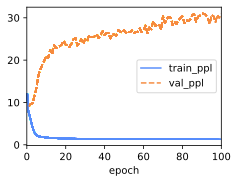

In [10]:
import torch
from d2l import torch as d2l

# 超参数
batch_size = 32
num_steps = 35
num_hiddens = 256
max_epochs = 100
lr = 1

# 数据
data = d2l.TimeMachine(batch_size=batch_size, num_steps=num_steps)

# 模型
rnn = d2l.RNN(num_inputs=len(data.vocab), num_hiddens=num_hiddens)
model = d2l.RNNLM(rnn, vocab_size=len(data.vocab), lr=lr)

# 设备
device = d2l.try_gpu()
model = model.to(device)

# 训练前先做一次预测
print(model.predict('time traveller', 10, data.vocab, device))

# 训练
num_gpus = 1 if torch.cuda.is_available() else 0
trainer = d2l.Trainer(
    max_epochs=max_epochs,
    gradient_clip_val=1,
    num_gpus=num_gpus
)
trainer.fit(model, data)

# 训练后再预测一次
print(model.predict('time traveller', 50, data.vocab, device))